### **Python DA Assignment 2 - Data Visualization**

**1) Loading the Taxis Dataset**

In [25]:
import seaborn as sns
# Load the 'taxis' dataset
df = sns.load_dataset("taxis")
df


,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


**2) Handling Missing Values**

##### Check for missing values in the dataset and identify columns with missing data.

In [26]:
df.isnull().sum()

,0
pickup,0
dropoff,0
passengers,0
distance,0
fare,0
tip,0
tolls,0
total,0
color,0
payment,44


##### Impute missing values using appropriate strategies based on the column type (e.g.,using mean, median, or mode for numerical columns and mode for categorical columns).

##### For columns that are critical and cannot be reasonably imputed, remove rows with missing values to maintain data integrity.

In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [ ]:
df['payment']=df['payment'].fillna('Unknown')
df

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6428,2019-03-31 09:51:53,2019-03-31 09:55:27,1,0.75,4.5,1.06,0.0,6.36,green,credit card,East Harlem North,Central Harlem North,Manhattan,Manhattan
6429,2019-03-31 17:38:00,2019-03-31 18:34:23,1,18.74,58.0,0.00,0.0,58.80,green,credit card,Jamaica,East Concourse/Concourse Village,Queens,Bronx
6430,2019-03-23 22:55:18,2019-03-23 23:14:25,1,4.14,16.0,0.00,0.0,17.30,green,cash,Crown Heights North,Bushwick North,Brooklyn,Brooklyn
6431,2019-03-04 10:09:25,2019-03-04 10:14:29,1,1.12,6.0,0.00,0.0,6.80,green,credit card,East New York,East Flatbush/Remsen Village,Brooklyn,Brooklyn


In [8]:
# Fill numerical columns with median
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum())

pickup             0
dropoff            0
passengers         0
distance           0
fare               0
tip                0
tolls              0
total              0
color              0
payment            0
pickup_zone        0
dropoff_zone       0
pickup_borough     0
dropoff_borough    0
dtype: int64


#### **3) Visualizations using Matplotlib/Pandas Plot:**

##### ★ **Line Chart**
#####    Plot a line chart to visualize the fare over time, using the pickup timestamp as the x-axis and fare as the y-axis. Ensure the pickup column is converted to a datetime format before plotting.

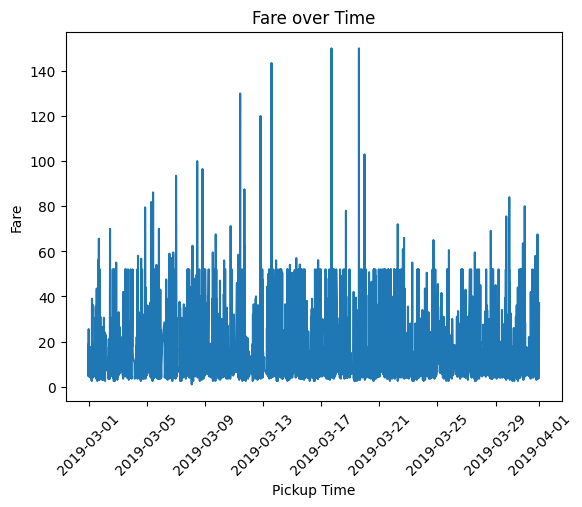

In [4]:
import matplotlib.pyplot as plt
import pandas as pd

df['pickup'] = pd.to_datetime(df['pickup'])

df_sorted = df.sort_values('pickup')

plt.figure()
plt.plot(df_sorted['pickup'], df_sorted['fare'])
plt.xlabel("Pickup Time")
plt.ylabel("Fare")
plt.title("Fare over Time")
plt.xticks(rotation=45)
plt.show()

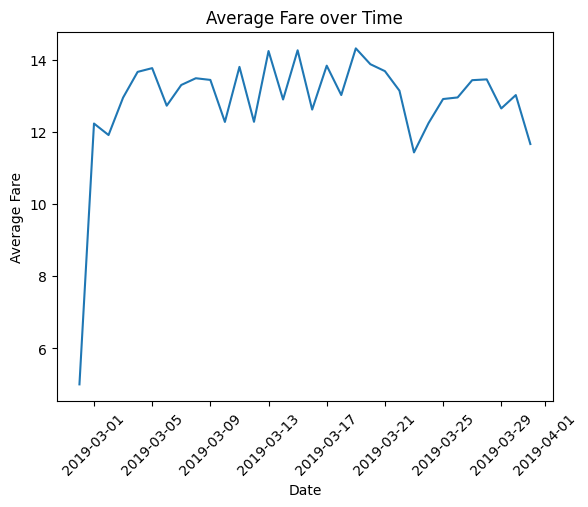

In [16]:
df['pickup'] = pd.to_datetime(df['pickup'])

df_grouped = df.groupby(df['pickup'].dt.date)['fare'].mean()

plt.figure()
plt.plot(df_grouped.index, df_grouped.values)
plt.xlabel("Date")
plt.ylabel("Average Fare")
plt.title("Average Fare over Time")
plt.xticks(rotation=45)
plt.show()

##### ★ **Bar Chart**
##### Create a bar chart to show the total fare for each pickup_borough. Group the data by pickup_borough and sum the fare for each group.

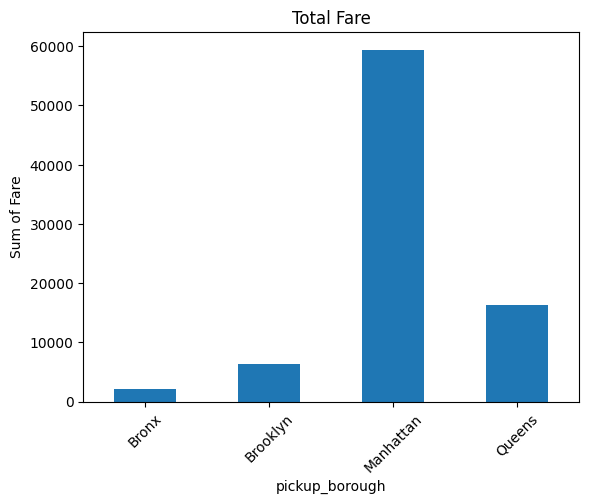

In [21]:
borough_fare = df.groupby(df['pickup_borough'])['fare'].sum()
borough_fare.plot(kind='bar')
plt.xlabel("pickup_borough")
plt.ylabel("Sum of Fare")
plt.title("Total Fare")
plt.xticks(rotation=45)
plt.show()

##### ★ **Pie Chart**
##### Plot a pie chart showing the distribution of trips based on the payment method (credit card, cash, etc.). Each slice should represent the count of trips for a specific payment method.

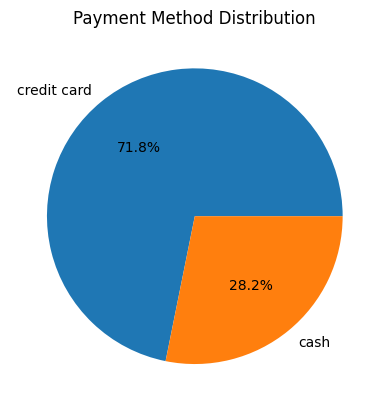

In [22]:
payment_counts = df['payment'].value_counts()

plt.figure()
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%')
plt.title("Payment Method Distribution")
plt.show()

##### ★ **Histogram**
##### Create a histogram to visualize the distribution of distance. Customize the number of bins for better granularity and ensure the plot is easy to interpret.

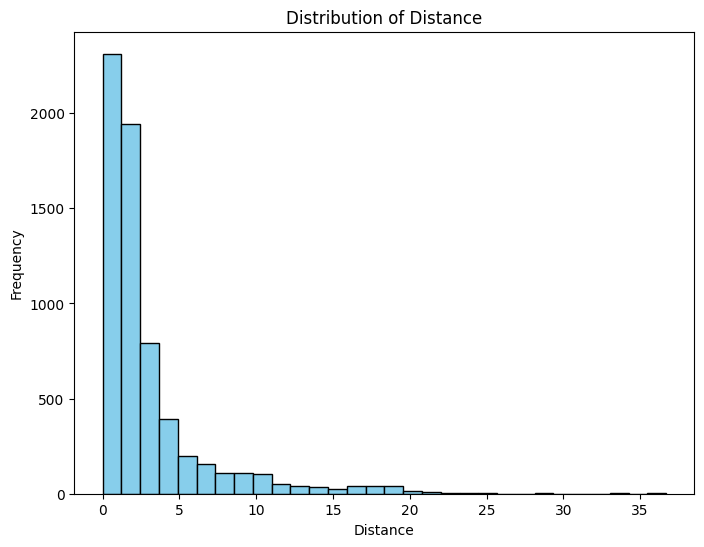

In [12]:
plt.figure(figsize=(8, 6))
plt.hist(df['distance'], bins=30,edgecolor='black',color='skyblue')
plt.xlabel("Distance")
plt.ylabel("Frequency")
plt.title("Distribution of Distance")
plt.show()

##### ★ **Box Plot**
##### Plot a box plot to visualize the distribution of tip amounts for each pickup_borough.Use pickup_borough as the categorical axis and tip as the numeric axis.

<Figure size 2000x1000 with 0 Axes>

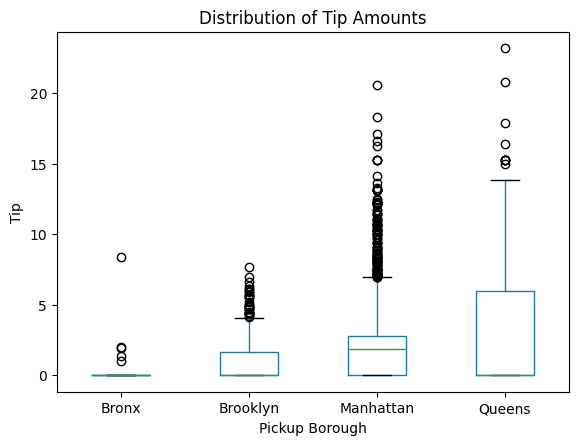

In [10]:
plt.figure(figsize=(20, 10))
df.boxplot(column='tip',by='pickup_borough',grid=False)
plt.xlabel("Pickup Borough")
plt.ylabel("Tip")
plt.title("Distribution of Tip Amounts")
plt.suptitle("")
plt.show()

#### **Visualizations using Seaborn:**

##### ★ **Count Plot**
##### Create a count plot to visualize the number of trips in each pickup_borough. The x-axis should represent the boroughs, and the y-axis should show the count of trips.

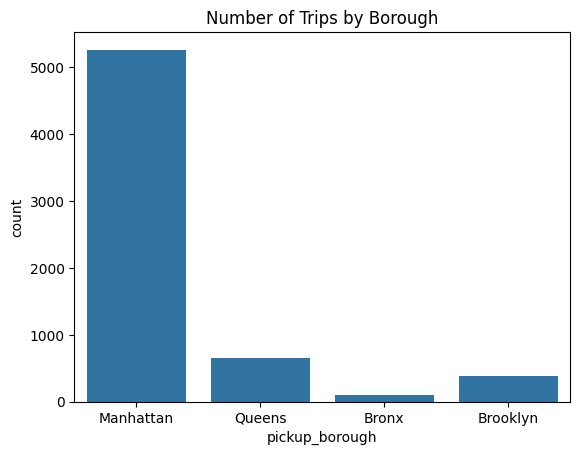

In [12]:
sns.countplot(data=df, x='pickup_borough')
plt.title("Number of Trips by Borough")
plt.show()

##### ★ **Scatter Plot**
##### Plot a scatter plot to show the relationship between distance and fare. Use distance on the x-axis and fare on the y-axis to visualize any correlation. Color the points based on the pickup_borough to differentiate the trips by their respective boroughs.

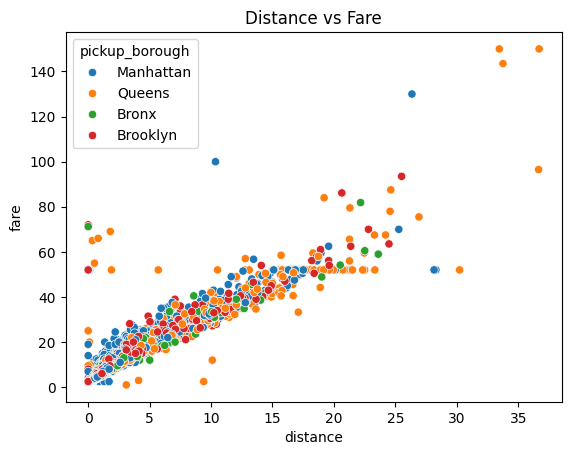

In [14]:
sns.scatterplot(x='distance', y='fare', hue='pickup_borough', data=df)
plt.title("Distance vs Fare")
plt.show()

##### ★ **Heatmap**
##### Plot a heatmap to visualize the correlation between numerical variables such as distance, fare, tip, tolls, and total. Use a correlation matrix to highlight the relationships.

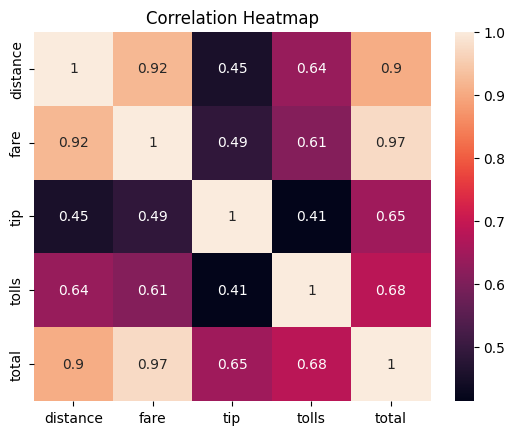

In [16]:
corr = df[['distance', 'fare', 'tip', 'tolls', 'total']].corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

##### ★ **Pair Plot**
##### Create a pair plot to visualize the pairwise relationships between distance, fare, tip and total. Color the data points according to the pickup_zone method to compare how different zones affect these variables.

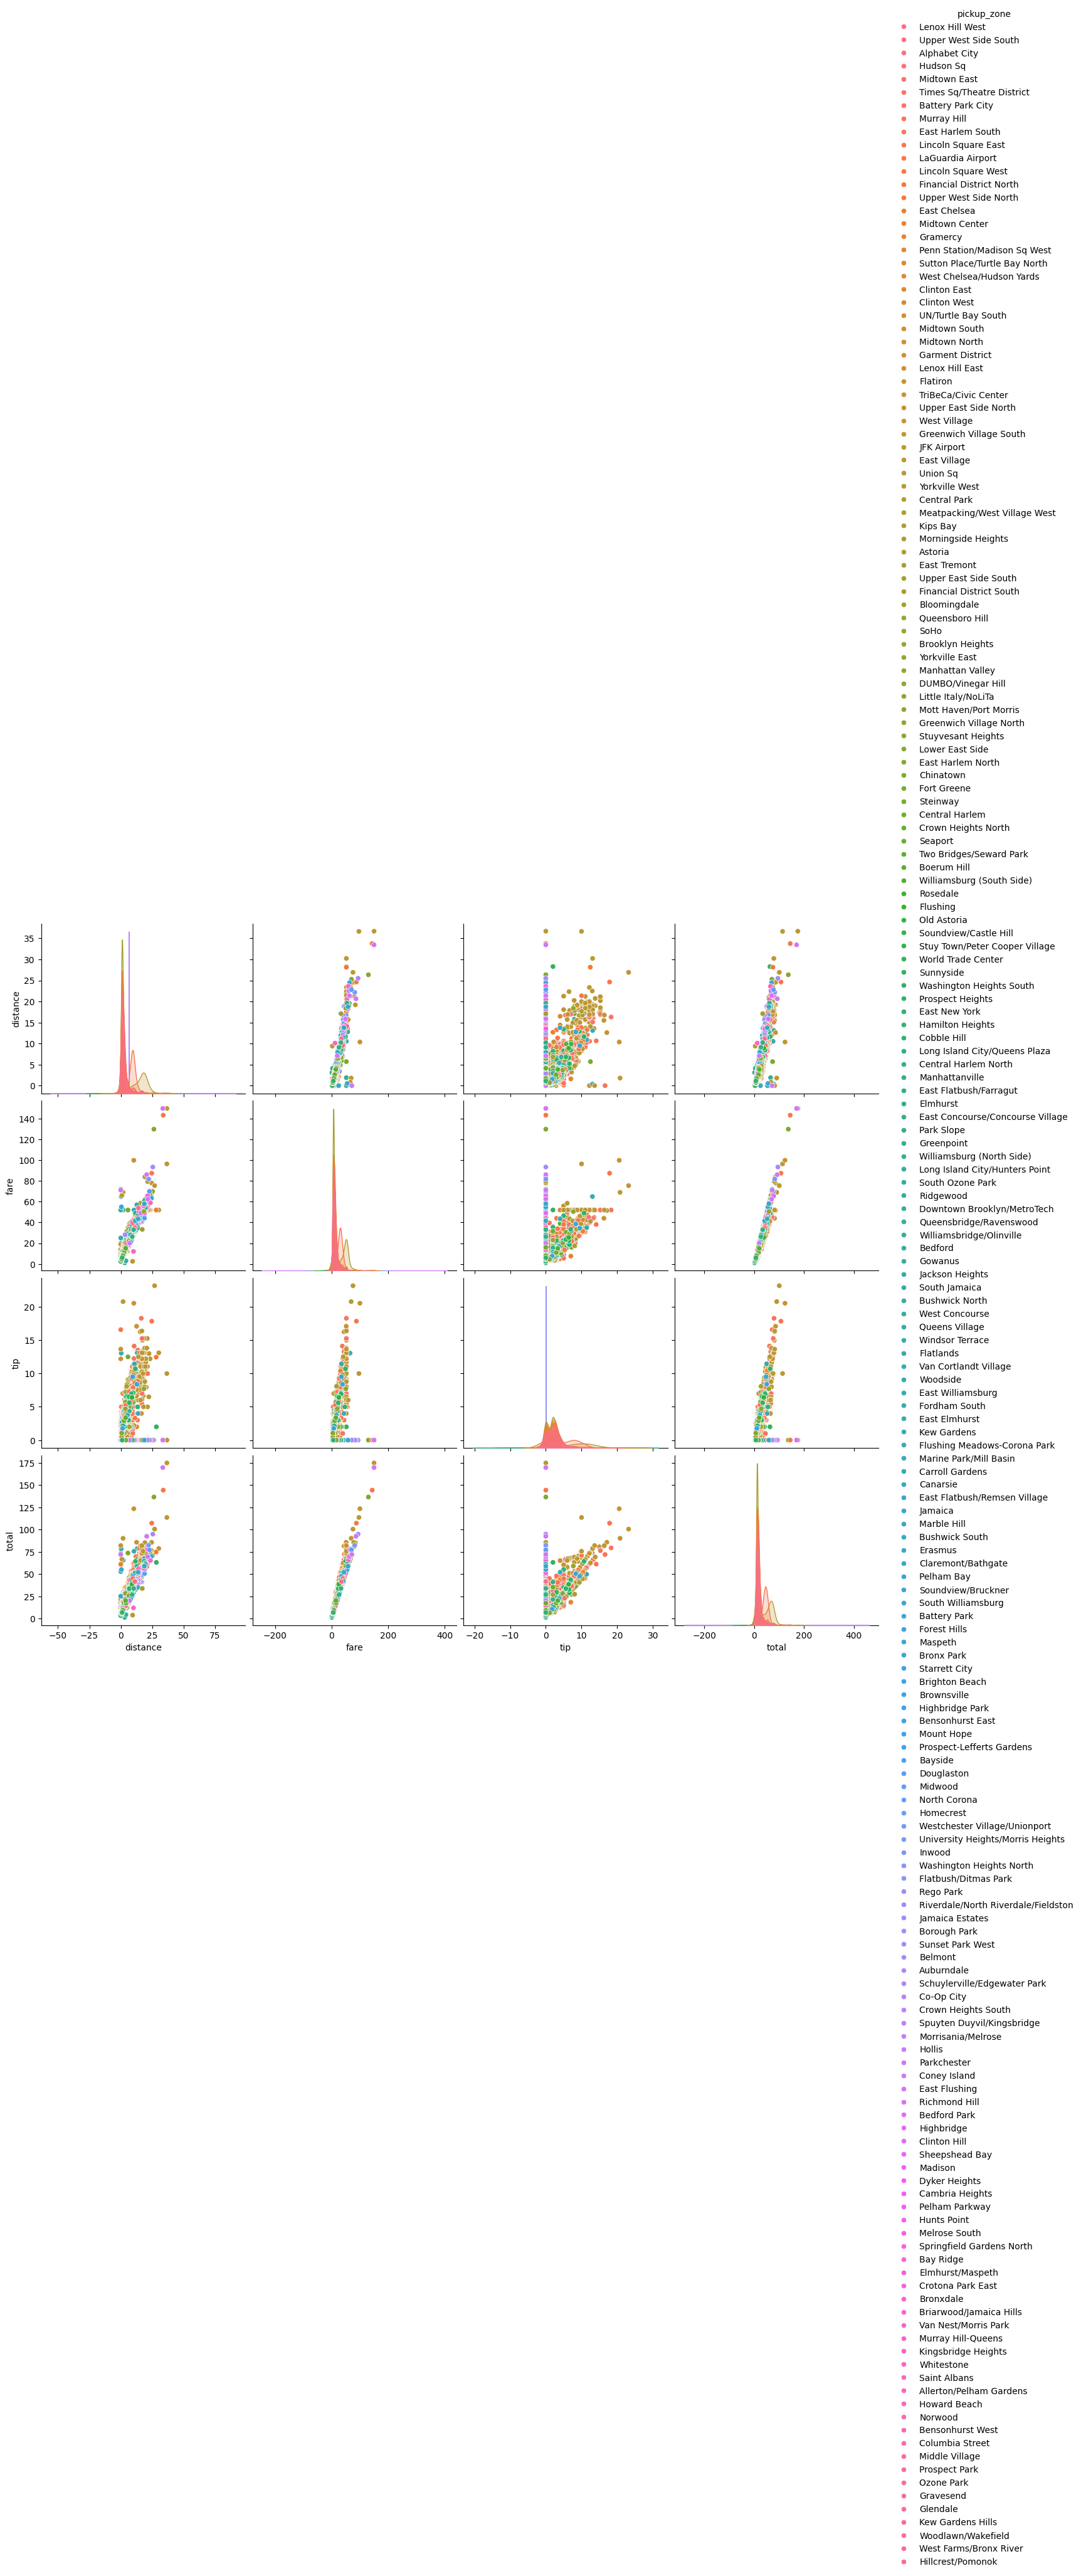

In [24]:
pp = df[['distance', 'fare', 'tip', 'total', 'pickup_zone']]
sns.pairplot(data=pp, hue='pickup_zone', height=3, aspect=1.2)
plt.show()

##### ★ **Violin Plot**
##### Plot a violin plot to show the distribution of fare for each payment method. Use the payment method as the categorical axis and fare as the numeric axis to visualize its distribution.

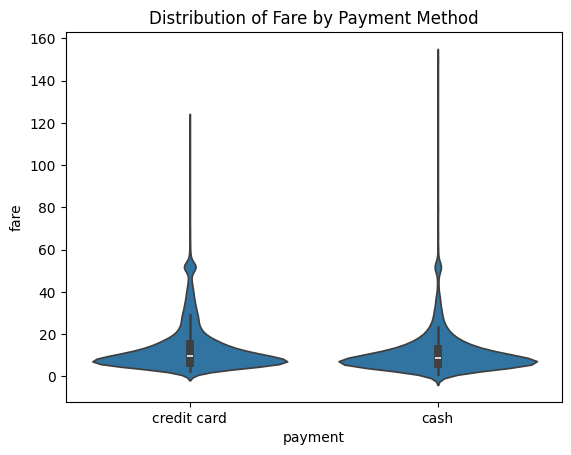

In [22]:
sns.violinplot(x='payment', y='fare', data=df)
plt.title("Distribution of Fare by Payment Method")
plt.show()